# Pregunta 4 — MANOVA factorial de lealtad

**Métodos Cuantitativos de la Investigación en Negocios — Tarea 2 (2026)**

In [1]:
# Instalación condicional de dependencias para Google Colab.
# En ejecución local no instala nada si los paquetes ya están disponibles.
import importlib, subprocess, sys

def instalar_si_falta(import_name, package_name=None):
    package_name = package_name or import_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f'Instalando {package_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

instalar_si_falta('pyreadstat', 'pyreadstat')
instalar_si_falta('pingouin', 'pingouin')

print('Dependencias verificadas y entorno inicial preparado.')


Dependencias verificadas y entorno inicial preparado.


## Enunciado de la pregunta 4

**4.** La empresa HBAT produce y vende productos de papel a dos industrias: Impresores de revistas e impresores de diarios. Los productos llegan a estos clientes a través de dos canales: Directo (Fuerza de Ventas) e Indirecto (Agentes). HBAT realizó una investigación de mercados en las que recolectó información en un sinnúmero de variables, métricas y no métricas, disponibles en el archivo `HBAT200.sav`, en una muestra de 200 clientes.

Entre las variables consideradas se encuentran algunas asociadas al resultado de compras y relación (5 variables), y variables descriptivas de las empresas de las cuales se recolecto información. Las variables se describen a continuación:

**Datos de Clasificación de las empresas encuestadas**

- X1 - Tipo de Cliente.
- X2 - Tipo de Industria.
- X3 - Tamaño de la Empresa.
- X4 - Región.
- X5 - Sistema de Distribución.

**Resultado de Compras y Relación con HBAT**

- X19 - Satisfacción.
- X20 - Intención de Recomendar a HBAT.
- X21 - Intención de Recomprar a HBAT.
- X22 - Nivel de Compras de HBAT.
- X23 - Considera Alianza Estratégica con HBAT.

Los ejecutivos de HBAT tienen diversas preguntas respecto a su desempeño y el nivel de satisfacción de sus clientes. En particular, están interesados en conocer el efecto de “Tamaño de la Empresa” y el “Tipo de Distribución” en la lealtad de los clientes, la cual consideran un constructo compuesto por tres variables: X19, Satisfacción; X20, Intención de Recomendar; X21, Intención de Recomprar.

En particular, desean determinar si:

**a)** ¿Incide el tipo de distribución en la lealtad de los clientes?  
**b)** ¿Se comportan los clientes de forma distinta en términos de su lealtad dependiendo de su tamaño?  
**c)** ¿Son las variables tipo de distribución y tamaño antecedentes independientes de la lealtad?

## Respuesta

Como la lealtad se mide mediante tres variables relacionadas, la pregunta se resuelve mediante un MANOVA factorial 2×2. Este enfoque permite evaluar simultáneamente el efecto del tipo de distribución, el tamaño de la empresa y su interacción sobre satisfacción, recomendación y recompra.


In [3]:
from pathlib import Path
from urllib.request import urlretrieve, urlopen
import ssl
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyreadstat
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

# Base requerida para este notebook.
# Funciona localmente y también en Google Colab abierto desde GitHub.
REQUIRED_DATA_FILE = 'HBAT_200.sav'
RAW_DATA_BASE = 'https://raw.githubusercontent.com/sebabecerra/Metodos-Cuantitativos-DEN/main/Tarea2/data'

def encontrar_o_descargar_base(filename):
    candidatas = [
        Path.cwd() / 'data',                 # ejecución desde Tarea2
        Path.cwd().parent / 'data',          # ejecución desde Tarea2/notebooks
        Path.cwd() / 'Tarea2' / 'data',      # ejecución desde raíz del repo o Colab
        Path.cwd()                           # respaldo: base junto al notebook
    ]
    for ruta in candidatas:
        if (ruta / filename).exists():
            return ruta

    # Si Colab no tiene la carpeta del repo clonada, se descarga la base desde GitHub.
    destino_dir = Path.cwd() / 'Tarea2' / 'data'
    destino_dir.mkdir(parents=True, exist_ok=True)
    destino = destino_dir / filename
    url = f'{RAW_DATA_BASE}/{filename}'
    print(f'Base {filename} no encontrada localmente. Descargando desde GitHub...')
    try:
        urlretrieve(url, destino)
    except Exception as error:
        # Respaldo útil en algunos entornos locales con problemas de certificados SSL.
        # En Colab normalmente no se activa, pero evita fallas si Python no encuentra certificados.
        print('Descarga estándar falló; intentando respaldo SSL...')
        contexto = ssl._create_unverified_context()
        with urlopen(url, context=contexto) as respuesta, open(destino, 'wb') as archivo:
            archivo.write(respuesta.read())
    return destino_dir

DATA_DIR = encontrar_o_descargar_base(REQUIRED_DATA_FILE)
print('Directorio de datos:', DATA_DIR)
print('Base usada:', DATA_DIR / REQUIRED_DATA_FILE)


Directorio de datos: /Users/sbc/projects/Metodos-Cuantitativos-DEN/Tarea2/data
Base usada: /Users/sbc/projects/Metodos-Cuantitativos-DEN/Tarea2/data/HBAT_200.sav


## 1. Diseño, procedimiento e hipótesis

La lealtad se representa mediante satisfacción, recomendación y recompra. Se aplica MANOVA factorial $2\times2$ con tipo de distribución y tamaño. Se prueban:

- H01: la distribución no se asocia conjuntamente con la lealtad.
- H02: el tamaño no se asocia conjuntamente con la lealtad.
- H03: distribución y tamaño actúan independientemente (sin interacción).

Tras MANOVA se analizan ANOVA univariados y medias de celdas.

In [3]:
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.anova import anova_lm
import pingouin as pg

# Chequeo inicial de la base.
# Se carga la base completa; no se filtran observaciones ni se toma una submuestra.
df, meta = pyreadstat.read_sav(DATA_DIR/'HBAT_200.sav', apply_value_formats=False)
dvs = ['Satisfaccion', 'Recomendacion', 'Recompra']
factores = ['Tipo_Dist', 'Tamaño_Empresa']

print('Archivo usado:', DATA_DIR/'HBAT_200.sav')
print('Número de observaciones:', len(df))
print('Número de variables:', df.shape[1])
print('Dimensión de la base:', df.shape)
print('Datos perdidos totales:', int(df[dvs + factores].isna().sum().sum()))
print('\nDatos perdidos por variable usada:')
print(df[dvs + factores].isna().sum().to_string())
print('\nCodificación observada de factores:')
for v in factores:
    print(f'\n{v}:')
    print(df[v].value_counts(dropna=False).sort_index().to_string())
print('\nTamaños de celda:')
print(df.groupby(['Tipo_Dist', 'Tamaño_Empresa']).size().rename('n').to_string())
print('\nDescriptivos de variables dependientes:')
print(df[dvs].describe().round(3).to_string())
print('\nMedias por celda:')
print(df.groupby(['Tipo_Dist', 'Tamaño_Empresa'])[dvs].mean().round(3).to_string())
print(f'\nF crítico univariado (95%; 1,196) = {stats.f.ppf(.95,1,196):.4f}')


Archivo usado: /Users/sbc/projects/Metodos-Cuantitativos-DEN/Tarea2/data/HBAT_200.sav
Número de observaciones: 200
Número de variables: 11
Dimensión de la base: (200, 11)
Datos perdidos totales: 0

Datos perdidos por variable usada:
Satisfaccion      0
Recomendacion     0
Recompra          0
Tipo_Dist         0
Tamaño_Empresa    0

Codificación observada de factores:

Tipo_Dist:
Tipo_Dist
0.0    108
1.0     92

Tamaño_Empresa:
Tamaño_Empresa
0.0     98
1.0    102

Tamaños de celda:
Tipo_Dist  Tamaño_Empresa
0.0        0.0               45
           1.0               63
1.0        0.0               53
           1.0               39

Descriptivos de variables dependientes:
       Satisfaccion  Recomendacion  Recompra
count       200.000        200.000   200.000
mean          6.952          6.952     7.665
std           1.241          1.083     0.893
min           4.700          4.000     4.300
25%           6.000          6.100     7.100
50%           7.050          7.000     7.600
75%

## 2. Consistencia de la medida de lealtad y supuestos

Se reportan alfa, correlaciones, Box M para igualdad de matrices de covarianza y Levene por variable. MANOVA es razonablemente robusto con tamaños similares; ante violaciones se privilegia Pillai, aunque también se presenta Wilks.

La consistencia se calcula con $\alpha=\tfrac{k}{k-1}\bigl(1-\tfrac{\sum_i s_i^2}{s_T^2}\bigr)$. Reemplazando ($k=3$, $\sum s_i^2=3.5109$, $s_T^2=8.4457$): $\alpha=\tfrac{3}{2}\bigl(1-\tfrac{3.5109}{8.4457}\bigr)=0.876$. Los estadísticos de comparación al 95% son $\chi^2_{0.95,18}=28.87$ para Box M y $F_{0.95;3,196}=2.6507$ para Levene: Box M (27.55) no supera su crítico, por lo que no se rechaza la igualdad de matrices de covarianza; Levene lo supera en satisfacción (4.93) y recompra (4.55), pero no en recomendación (1.72).

In [7]:
def alpha(d):
 k=d.shape[1]; return k/(k-1)*(1-d.var(ddof=1).sum()/d.sum(axis=1).var(ddof=1))
print('Alfa lealtad=',round(alpha(df[dvs]),4)); print('\nCorrelaciones:\n',df[dvs].corr().round(3).to_string())
df['grupo']=df.Tipo_Dist.astype(str)+'_'+df.Tamaño_Empresa.astype(str)
print('\nBox M:\n',pg.box_m(df,dvs=dvs,group='grupo').round(4).to_string())
for v in dvs:
 grupos=[g[v] for _,g in df.groupby('grupo')]; st,p=stats.levene(*grupos); print(f'Levene {v}: F={st:.4f}, p={p:.4g}')
print(f'\nchi2 crítico Box M (95%, gl=18) = {stats.chi2.ppf(.95,18):.4f}')
print(f'F crítico Levene (95%; 3,196) = {stats.f.ppf(.95,3,196):.4f}')

Alfa lealtad= 0.8764

Correlaciones:
                Satisfaccion  Recomendacion  Recompra
Satisfaccion          1.000          0.762     0.726
Recomendacion         0.762          1.000     0.661
Recompra              0.726          0.661     1.000

Box M:
        Chi2    df    pval  equal_cov
box  27.551  18.0  0.0692       True
Levene Satisfaccion: F=4.9332, p=0.00252
Levene Recomendacion: F=1.7195, p=0.1643
Levene Recompra: F=4.5532, p=0.004149

chi2 crítico Box M (95%, gl=18) = 28.8693
F crítico Levene (95%; 3,196) = 2.6507


## 3. MANOVA factorial

La interacción prueba directamente si distribución y tamaño son antecedentes independientes. Si es significativa, la asociación de una variable varía según el nivel de la otra.

Con efectos de un grado de libertad (diseño $2\times2$), las cuatro pruebas multivariadas (Pillai, Wilks, Hotelling y Roy) producen exactamente el mismo $F$, y este se obtiene directamente de $\Lambda$ mediante

$$F=\frac{1-\Lambda}{\Lambda}\cdot\frac{gl_2}{gl_1}.$$

Por ejemplo, para distribución: $F=\tfrac{1-0.8526}{0.8526}\cdot\tfrac{194}{3}=11.18$. El estadístico de comparación al 95% es $F_{0.95;3,194}=2.6512$: se rechaza cada $H_0$ cuyo $F$ observado lo supere.

In [9]:
ma=MANOVA.from_formula('Satisfaccion + Recomendacion + Recompra ~ C(Tipo_Dist) * C(Tamaño_Empresa)',df)
print(ma.mv_test())
print(f'F crítico multivariado (95%; 3,194) = {stats.f.ppf(.95,3,194):.4f}')

                      Multivariate linear model
                                                                     
----------------------------------------------------------------------
        Intercept          Value   Num DF   Den DF    F Value   Pr > F
----------------------------------------------------------------------
           Wilks' lambda   0.0436  3.0000  194.0000  1419.8017  0.0000
          Pillai's trace   0.9564  3.0000  194.0000  1419.8017  0.0000
  Hotelling-Lawley trace  21.9557  3.0000  194.0000  1419.8017  0.0000
     Roy's greatest root  21.9557  3.0000  194.0000  1419.8017  0.0000
---------------------------------------------------------------------
                                                                     
----------------------------------------------------------------------
          C(Tipo_Dist)       Value   Num DF   Den DF   F Value  Pr > F
----------------------------------------------------------------------
              Wilks' lambda  0.8

## 4. ANOVA univariados y tamaño de efecto

Se calcula eta cuadrado parcial $\eta_p^2=SC_{efecto}/(SC_{efecto}+SC_{error})$.

El estadístico de comparación de los ANOVA univariados al 95% es $F_{0.95;1,196}=3.8893$; se rechaza $H_0$ cuando el $F$ observado lo supera. A modo de ilustración del tamaño de efecto, para la interacción en satisfacción: $\eta_p^2=\tfrac{15.3264}{15.3264+174.0669}=0.081$.

Dado que se realizan tres pruebas univariadas por familia de efectos, se usa como referencia adicional la corrección de Bonferroni: $\alpha=0.05/3=0.0167$. Con este criterio, la interacción sigue siendo significativa en satisfacción ($p<0.001$) y en recompra ($p=0.0099<0.0167$), y no significativa en recomendación ($p=0.221$).

In [11]:
for v in dvs:
 fit=smf.ols(f'{v} ~ C(Tipo_Dist) * C(Tamaño_Empresa)',df).fit(); tab=anova_lm(fit,typ=2); err=tab.loc['Residual','sum_sq']; tab['eta2_parcial']=tab.sum_sq/(tab.sum_sq+err)
 print('\n',v); print(tab.round(4).to_string())
print(f'\nF crítico univariado (95%; 1,196) = {stats.f.ppf(.95,1,196):.4f}')
print(f'F crítico univariado con Bonferroni (alfa=0.05/3; 1,196) = {stats.f.ppf(1-0.05/3,1,196):.4f}')


 Satisfaccion
                                  sum_sq     df         F  PR(>F)  eta2_parcial
C(Tipo_Dist)                    105.6251    1.0  118.9343     0.0        0.3776
C(Tamaño_Empresa)                24.8461    1.0   27.9768     0.0        0.1249
C(Tipo_Dist):C(Tamaño_Empresa)   15.3264    1.0   17.2576     0.0        0.0809
Residual                        174.0669  196.0       NaN     NaN        0.5000

 Recomendacion
                                  sum_sq     df        F  PR(>F)  eta2_parcial
C(Tipo_Dist)                     63.0323    1.0  83.1164  0.0000        0.2978
C(Tamaño_Empresa)                32.9133    1.0  43.4006  0.0000        0.1813
C(Tipo_Dist):C(Tamaño_Empresa)    1.1417    1.0   1.5055  0.2213        0.0076
Residual                        148.6389  196.0      NaN     NaN        0.5000

 Recompra
                                  sum_sq     df        F  PR(>F)  eta2_parcial
C(Tipo_Dist)                     31.7444    1.0  55.4024  0.0000        0.2204
C(Tam

In [12]:

# Diagnósticos multivariados adicionales: Mardia y Mahalanobis.
# Estos diagnósticos complementan Box M, Levene y la elección de Pillai.
X = df[dvs].to_numpy(float)
media = X.mean(axis=0)
S = np.cov(X, rowvar=False)
Sinv = np.linalg.inv(S)
D = (X - media) @ Sinv @ (X - media).T
b1p = np.mean(D**3)
md2 = np.diag(D)
b2p = np.mean(md2**2)
n, p_dim = X.shape
skew_stat = n * b1p / 6
skew_df = p_dim * (p_dim + 1) * (p_dim + 2) // 6
skew_p = 1 - stats.chi2.cdf(skew_stat, skew_df)
z_kurt = (b2p - p_dim * (p_dim + 2)) / np.sqrt(8 * p_dim * (p_dim + 2) / n)
kurt_p = 2 * (1 - stats.norm.cdf(abs(z_kurt)))
mah_cut = stats.chi2.ppf(.999, p_dim)
print(f'Mardia asimetría: b1p={b1p:.4f}, chi2={skew_stat:.4f}, gl={skew_df}, p={skew_p:.4f}')
print(f'Mardia curtosis: b2p={b2p:.4f}, z={z_kurt:.4f}, p={kurt_p:.4f}')
print(f'Mahalanobis máximo={md2.max():.4f}; corte chi2(.999,3)={mah_cut:.4f}; casos sobre corte={(md2 > mah_cut).sum()}')

# Efectos simples con pruebas t de Welch y corrección Bonferroni por variable dependiente.
filas = []
for dv in dvs:
    for size_val, size_lab in [(0, 'Pequeña'), (1, 'Grande')]:
        directa = df[(df.Tipo_Dist == 1) & (df.Tamaño_Empresa == size_val)][dv]
        indirecta = df[(df.Tipo_Dist == 0) & (df.Tamaño_Empresa == size_val)][dv]
        t_stat, p_val = stats.ttest_ind(directa, indirecta, equal_var=False)
        va, vb = directa.var(ddof=1), indirecta.var(ddof=1)
        na, nb_ = len(directa), len(indirecta)
        gl = (va/na + vb/nb_)**2 / ((va/na)**2/(na-1) + (vb/nb_)**2/(nb_-1))
        filas.append([dv, f'Directa - indirecta | {size_lab}', directa.mean() - indirecta.mean(), t_stat, gl, p_val])
    for dist_val, dist_lab in [(0, 'Indirecta'), (1, 'Directa')]:
        grande = df[(df.Tipo_Dist == dist_val) & (df.Tamaño_Empresa == 1)][dv]
        pequena = df[(df.Tipo_Dist == dist_val) & (df.Tamaño_Empresa == 0)][dv]
        t_stat, p_val = stats.ttest_ind(grande, pequena, equal_var=False)
        va, vb = grande.var(ddof=1), pequena.var(ddof=1)
        na, nb_ = len(grande), len(pequena)
        gl = (va/na + vb/nb_)**2 / ((va/na)**2/(na-1) + (vb/nb_)**2/(nb_-1))
        filas.append([dv, f'Grande - pequeña | {dist_lab}', grande.mean() - pequena.mean(), t_stat, gl, p_val])

efectos_simples = pd.DataFrame(filas, columns=['Variable', 'Comparación', 'Diferencia', 't_Welch', 'gl', 'p'])
efectos_simples['p_Bonf'] = np.minimum(efectos_simples['p'] * 4, 1)
print('\nEfectos simples Welch con Bonferroni por variable dependiente:')
print(efectos_simples.round({'Diferencia': 3, 't_Welch': 3, 'gl': 2, 'p': 4, 'p_Bonf': 4}).to_string(index=False))


Mardia asimetría: b1p=0.3289, chi2=10.9630, gl=10, p=0.3604
Mardia curtosis: b2p=14.4609, z=-0.6960, p=0.4864
Mahalanobis máximo=17.5371; corte chi2(.999,3)=16.2662; casos sobre corte=1

Efectos simples Welch con Bonferroni por variable dependiente:
     Variable                   Comparación  Diferencia  t_Welch    gl      p  p_Bonf
 Satisfaccion Directa - indirecta | Pequeña       0.917    4.487 82.48 0.0000  0.0001
 Satisfaccion  Directa - indirecta | Grande       2.042   11.855 94.68 0.0000  0.0000
 Satisfaccion  Grande - pequeña | Indirecta       0.195    0.946 86.65 0.3466  1.0000
 Satisfaccion    Grande - pequeña | Directa       1.320    7.767 87.34 0.0000  0.0000
Recomendacion Directa - indirecta | Pequeña       0.988    5.451 83.89 0.0000  0.0000
Recomendacion  Directa - indirecta | Grande       1.295    7.539 86.85 0.0000  0.0000
Recomendacion  Grande - pequeña | Indirecta       0.680    3.689 89.62 0.0004  0.0015
Recomendacion    Grande - pequeña | Directa       0.987    5.8

## Gráfico de interacción

Se grafica la media de satisfacción por celda. Las rectas no paralelas ilustran la interacción: la ventaja de la distribución directa es mayor entre las empresas grandes. Este gráfico respalda la Figura 6 del documento.

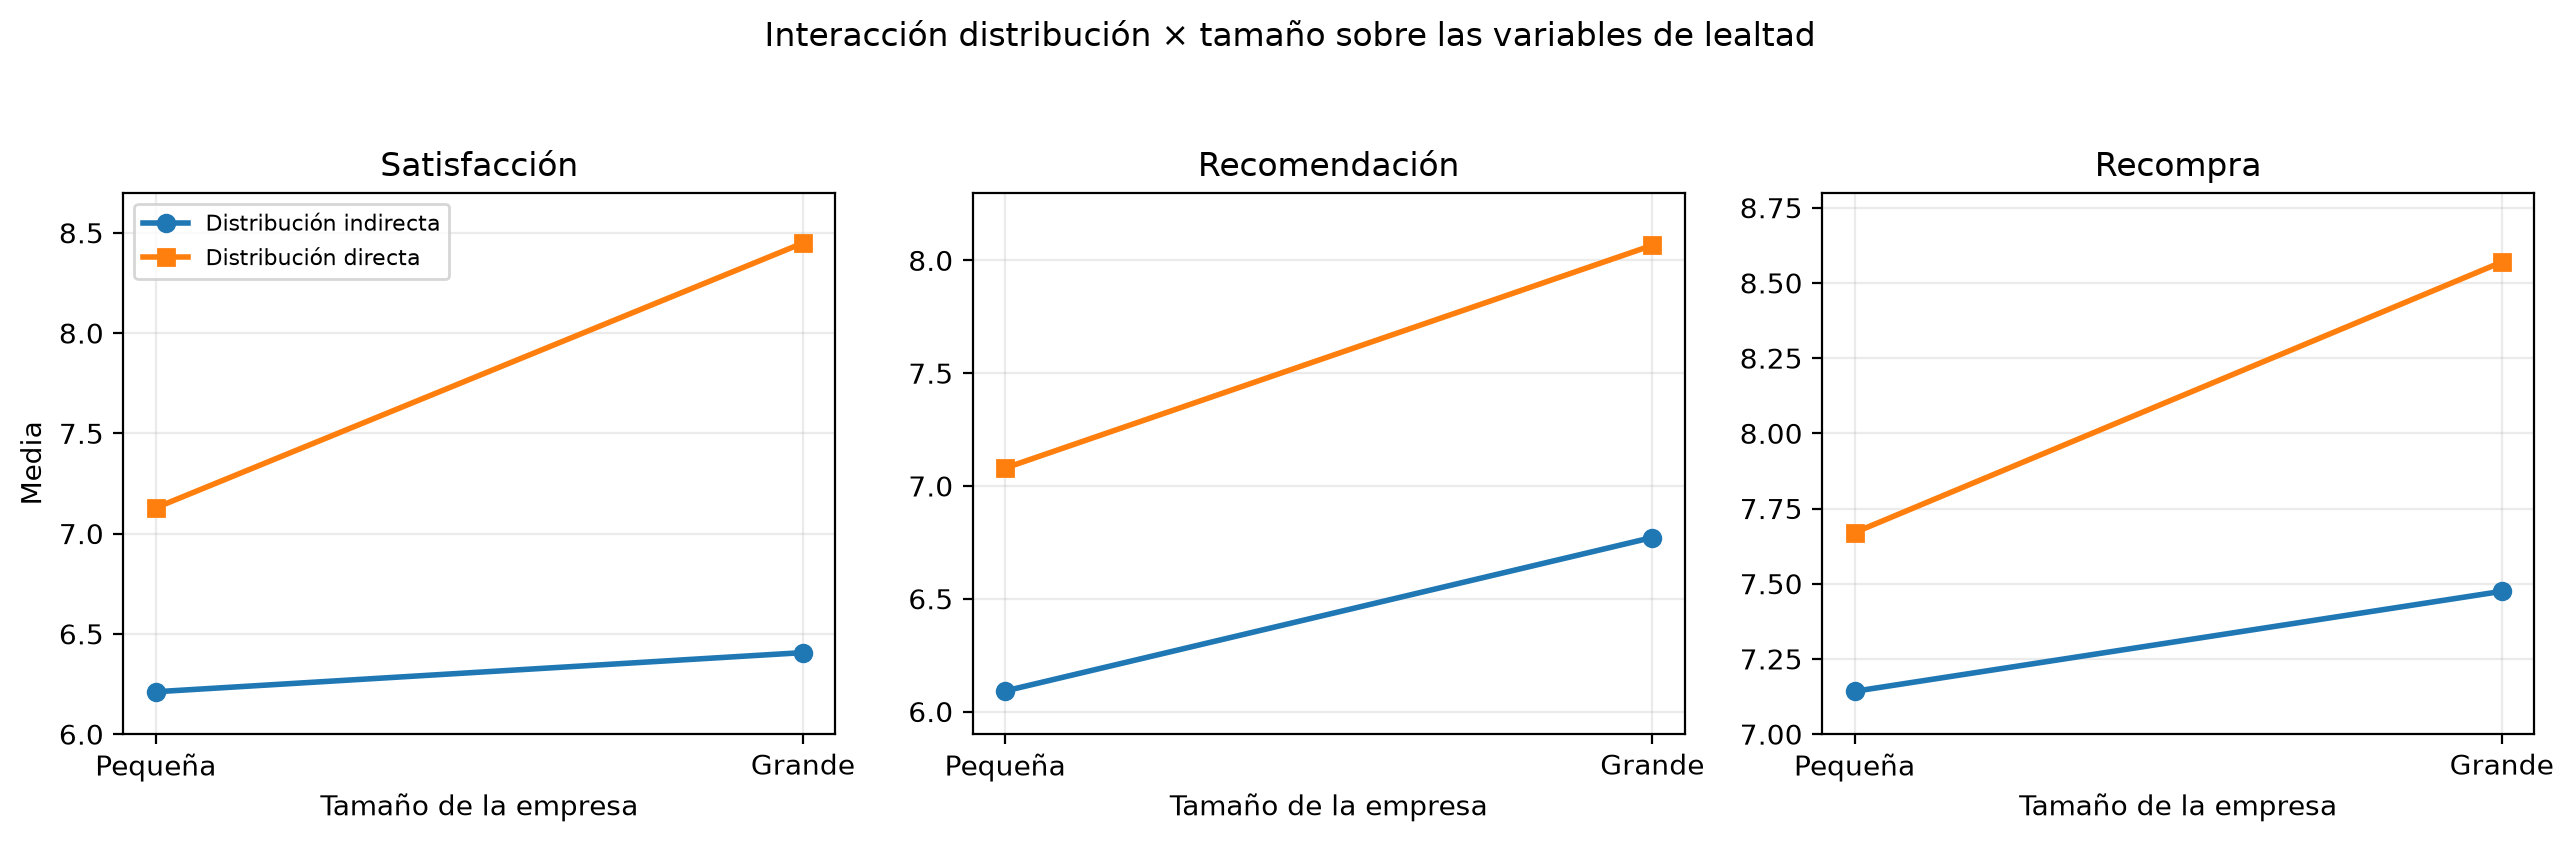

Figura guardada: ../assets/p4_interaccion_lealtad.png


In [14]:
# Figura integrada de interacción para las tres variables dependientes.
# Cada panel muestra las medias por tamaño de empresa y tipo de distribución.
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
ASSETS_DIR = Path('../assets')
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

labels_tam = {0.0: 'Pequeña', 1.0: 'Grande'}
labels_dist = {0.0: 'Distribución indirecta', 1.0: 'Distribución directa'}
colors = {0.0: '#1f77b4', 1.0: '#ff7f0e'}
markers = {0.0: 'o', 1.0: 's'}

y_lims = {
    'Satisfaccion': (6.0, 8.7),
    'Recomendacion': (5.9, 8.3),
    'Recompra': (7.0, 8.8),
}

titles = {
    'Satisfaccion': 'Satisfacción',
    'Recomendacion': 'Recomendación',
    'Recompra': 'Recompra',
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, dv in zip(axes, dvs):
    for dist_val in [0.0, 1.0]:
        medias = []
        for tam_val in [0.0, 1.0]:
            media = df[(df['Tipo_Dist'] == dist_val) & (df['Tamaño_Empresa'] == tam_val)][dv].mean()
            medias.append(media)
        ax.plot([0, 1], medias, marker=markers[dist_val], color=colors[dist_val], linewidth=2, label=labels_dist[dist_val])
    ax.set_title(titles[dv])
    ax.set_xticks([0, 1], ['Pequeña', 'Grande'])
    ax.set_xlabel('Tamaño de la empresa')
    ax.set_ylim(*y_lims[dv])
    ax.grid(alpha=.25)
axes[0].set_ylabel('Media')
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('Interacción distribución × tamaño sobre las variables de lealtad', y=1.04)
fig.tight_layout()
fig.savefig(ASSETS_DIR / 'p4_interaccion_lealtad.png', dpi=200, bbox_inches='tight')
plt.close(fig)
display(Image(str(ASSETS_DIR / 'p4_interaccion_lealtad.png')))
print(f'Figura guardada: {ASSETS_DIR / 'p4_interaccion_lealtad.png'}')

## 5. Efectos simples

Dado que existe interacción multivariada, las medias permiten interpretar dónde cambia el efecto. Se comparan distribución directa versus indirecta dentro de cada tamaño y tamaño grande versus pequeño dentro de cada distribución.

Se reportan 12 contrastes $t$ de Welch. Con corrección de Bonferroni por familia ($\alpha=0.05/4=0.0125$ por variable dependiente) todas las conclusiones se mantienen: los contrastes significativos conservan $p<0.0125$ y los no significativos, como grande–pequeña bajo distribución indirecta en satisfacción ($p=0.347$) y recompra ($p=0.064$), siguen siéndolo.

In [16]:
for v in dvs:
 print('\n',v)
 for tam in [0,1]:
  a=df[(df.Tamaño_Empresa==tam)&(df.Tipo_Dist==0)][v]; b=df[(df.Tamaño_Empresa==tam)&(df.Tipo_Dist==1)][v]
  t,p=stats.ttest_ind(b,a,equal_var=False); print(f'Directa-Indirecta, tamaño {tam}: diferencia={b.mean()-a.mean():.3f}, t={t:.3f}, p={p:.4g}')
 for dist in [0,1]:
  a=df[(df.Tipo_Dist==dist)&(df.Tamaño_Empresa==0)][v]; b=df[(df.Tipo_Dist==dist)&(df.Tamaño_Empresa==1)][v]
  t,p=stats.ttest_ind(b,a,equal_var=False); print(f'Grande-Pequeña, distribución {dist}: diferencia={b.mean()-a.mean():.3f}, t={t:.3f}, p={p:.4g}')


 Satisfaccion
Directa-Indirecta, tamaño 0: diferencia=0.917, t=4.487, p=2.318e-05
Directa-Indirecta, tamaño 1: diferencia=2.042, t=11.855, p=2.054e-20
Grande-Pequeña, distribución 0: diferencia=0.195, t=0.946, p=0.3466
Grande-Pequeña, distribución 1: diferencia=1.320, t=7.767, p=1.437e-11

 Recomendacion
Directa-Indirecta, tamaño 0: diferencia=0.988, t=5.451, p=4.932e-07
Directa-Indirecta, tamaño 1: diferencia=1.295, t=7.539, p=4.279e-11
Grande-Pequeña, distribución 0: diferencia=0.680, t=3.689, p=0.0003856
Grande-Pequeña, distribución 1: diferencia=0.987, t=5.862, p=9.628e-08

 Recompra
Directa-Indirecta, tamaño 0: diferencia=0.528, t=3.176, p=0.002273
Directa-Indirecta, tamaño 1: diferencia=1.095, t=7.606, p=2.753e-11
Grande-Pequeña, distribución 0: diferencia=0.332, t=1.878, p=0.06404
Grande-Pequeña, distribución 1: diferencia=0.899, t=6.901, p=1.689e-09


## 6. Conclusión

La medida de lealtad es confiable ($\alpha=0.876$). La distribución incide en la combinación de resultados, Pillai $V=0.147$, $F(3,194)=11.184$, $p<0.001$; el tamaño también, $V=0.097$, $F(3,194)=6.959$, $p<0.001$. Se rechazan H01 y H02. (Con efectos de un grado de libertad, Wilks entrega el mismo $F$.)

La interacción distribución×tamaño también es significativa, Pillai $V=0.097$, $F(3,194)=6.917$, $p<0.001$: **no son antecedentes independientes**. En los ANOVA, la interacción aparece en satisfacción ($p<0.001$) y recompra ($p=0.0099$), pero no en recomendación ($p=0.221$). Las empresas grandes con distribución directa presentan las mayores medias: satisfacción 8.449, recomendación 8.067 y recompra 8.569. El beneficio de distribución directa es especialmente fuerte en empresas grandes.